In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
#Load the Data
data = pd.read_csv(r"/content/IMBD Data.zip")

In [6]:
data.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
#data preprocessing
data.replace({"sentiment": {"positive" :1 , "negative":0}} ,inplace = True)

/tmp/ipykernel_290/3047840506.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment": {"positive" :1 , "negative":0}} ,inplace = True)


In [8]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [9]:
print("Duplicates in Dataset: ",data.duplicated().sum())
data.drop_duplicates(inplace = True)

Duplicates in Dataset:  418


In [10]:
# Convert reviews to lowercase
data['review'] = data['review'].str.lower()

In [11]:
# Remove HTML tags from reviews
import re
def remove_html_tags(text):
    pattern = r'[^a-zA-Z0-9\s]'
    text = re.sub(pattern,'',text)
    return text

data['review'] = data['review'].apply(remove_html_tags)



In [12]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

data['review']=data['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
# Remove URLs from reviews
data['review'] = data['review'].str.replace('http\S+|www.\S+', '', case=False)

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_290/3233631052.py:2: SyntaxWarning: invalid escape sequence '\S'
  data['review'] = data['review'].str.replace('http\S+|www.\S+', '', case=False)


In [14]:
# Split data into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

#Tokenize and Pad Sequence


In [15]:
# Tokenize text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data["review"])
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)


In [16]:
# Prepare target variables
Y_train = train_data["sentiment"]
Y_test = test_data["sentiment"]


Build and Train LSTM model

In [17]:
# Build the LSTM model
model = Sequential()
# input_dim = tokenizer size
# output_dim = dimension of vector that you want to represent
model.add(Embedding(input_dim=5000, output_dim=128 ,  input_shape=(200,)))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Display model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


In [20]:
# Train the model
history = model.fit(X_train, Y_train, epochs=7, batch_size=64, validation_split=0.2)

Epoch 1/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 358s 708ms/step - accuracy: 0.7726 - loss: 0.4677 - val_accuracy: 0.8700 - val_loss: 0.3126
Epoch 2/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 351s 708ms/step - accuracy: 0.8873 - loss: 0.2826 - val_accuracy: 0.8733 - val_loss: 0.3053
Epoch 3/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 352s 709ms/step - accuracy: 0.9098 - loss: 0.2305 - val_accuracy: 0.8645 - val_loss: 0.3441
Epoch 4/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 349s 704ms/step - accuracy: 0.9191 - loss: 0.2053 - val_accuracy: 0.8644 - val_loss: 0.3384
Epoch 5/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 349s 704ms/step - accuracy: 0.9379 - loss: 0.1656 - val_accuracy: 0.8671 - val_loss: 0.3495
Epoch 6/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 351s 708ms/step - accuracy: 0.9458 - loss: 0.1477 - val_accuracy: 0.8642 - val_loss: 0.3965
Epoch 7/7
496/496 ━━━━━━━━━━━━━━━━━━━━ 356s 718ms/step - accuracy: 0.9549 - loss: 0.1242 - val_accuracy: 0.8617 - val_loss: 0.4127


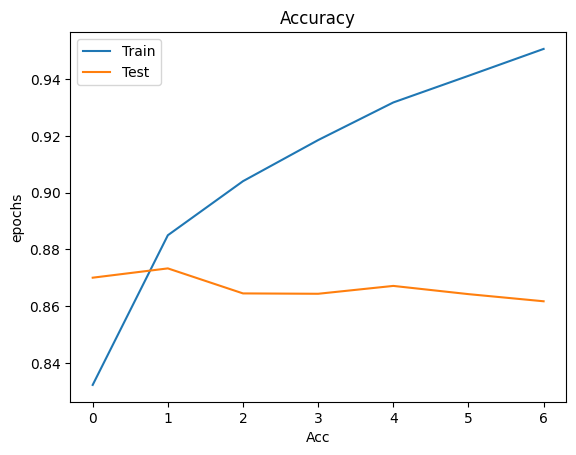

In [21]:
# Plot training and validation accuracy
plt.figure()
plt.plot(history.history["accuracy"], label = "Train")
plt.plot(history.history["val_accuracy"], label = "Test")
plt.title("Accuracy")
plt.ylabel("epochs")
plt.xlabel("Acc")
plt.legend()
plt.show()


In [22]:
# Evaluating the model
loss,accuracy=model.evaluate(X_test,Y_test)
print(f"Test Loss:{loss}")
print(f"Test accuracy:{accuracy}")

310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 0.8619 - loss: 0.4117
Test Loss:0.4114115238189697
Test accuracy:0.864172637462616


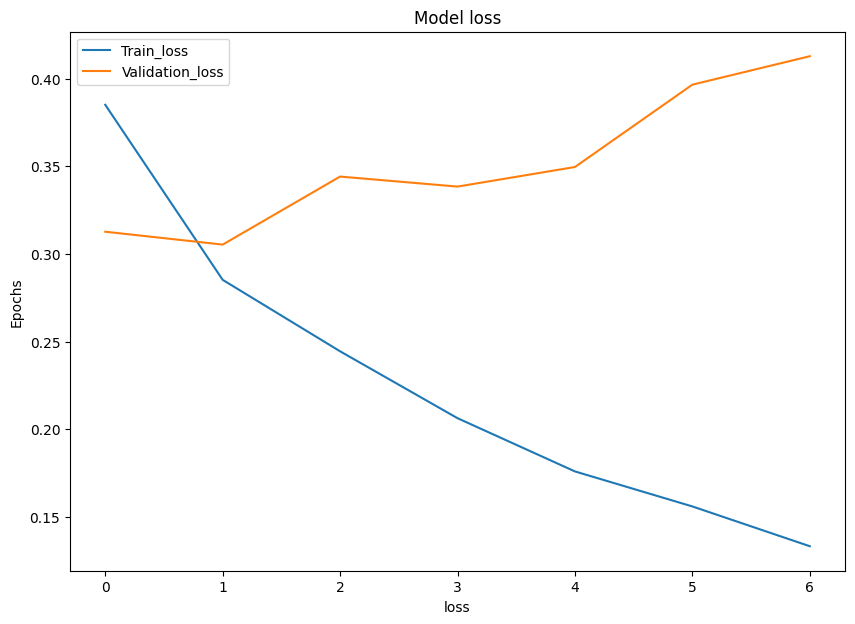

In [23]:
# plot loss graph
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('loss')
plt.ylabel('Epochs')
plt.legend(['Train_loss', 'Validation_loss'])
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [25]:
# Predict probabilities
y_pred = model.predict(X_test)

# Convert probabilities into classes (0 or 1)
y_pred_classes = (y_pred > 0.5).astype(int)

310/310 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step


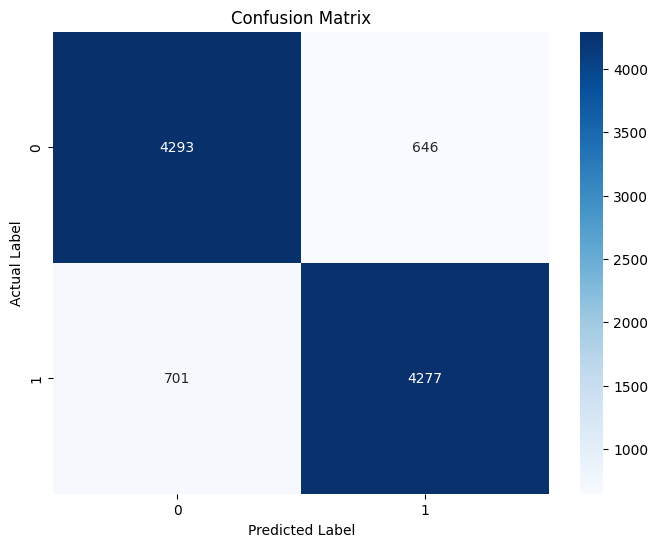

In [26]:
cm = confusion_matrix(Y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [27]:
print("Classification Report:\n")

print(classification_report(Y_test, y_pred_classes))

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4939
           1       0.87      0.86      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



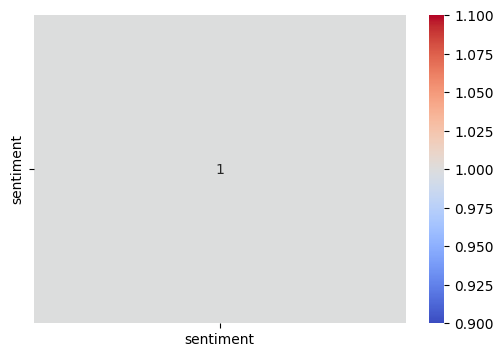

In [28]:
# Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
corr = data.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()